1. Import et Embedding des DAM

In [7]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
import os
import numpy as np
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import random

# --- Bloc 1 : Initialisation des modèles et des embeddings ---

# Define dataset class
class ImageDataset(Dataset):
    def __init__(self, image_folder, transform=None):
        self.image_folder = image_folder
        self.image_paths = [os.path.join(image_folder, img) for img in os.listdir(image_folder)]
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, image_path

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Paths to folders
dam_folder = r"C:\Users\Erwan\Documents\Etudes Erwan\CentraleSupélec\Cours 2024-2025\Mention IA\HeadMind Classification\ChallengeAIHeadmindPartners\data\DAM"
test_folder = r"C:\Users\Erwan\Documents\Etudes Erwan\CentraleSupélec\Cours 2024-2025\Mention IA\HeadMind Classification\ChallengeAIHeadmindPartners\data\test_image_headmind"

# Load DAM dataset
dam_dataset = ImageDataset(dam_folder, transform=transform)
dam_loader = DataLoader(dam_dataset, batch_size=32, shuffle=False)

# Load pretrained ResNet and remove the final layer
resnet = models.resnet50(pretrained=True)
resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()

# Function to extract embeddings
def extract_embeddings(loader, model):
    embeddings = []
    image_paths = []
    with torch.no_grad():
        for images, paths in loader:
            images = images
            outputs = model(images).squeeze()  # Flatten the embeddings
            embeddings.append(outputs.cpu().numpy())
            image_paths.extend(paths)
    embeddings = np.vstack(embeddings)
    return embeddings, image_paths

# Extract embeddings for DAM images (Run this only once)
dam_embeddings, dam_paths = extract_embeddings(dam_loader, resnet)

2. Tirage aléatoire et similarité cosinus

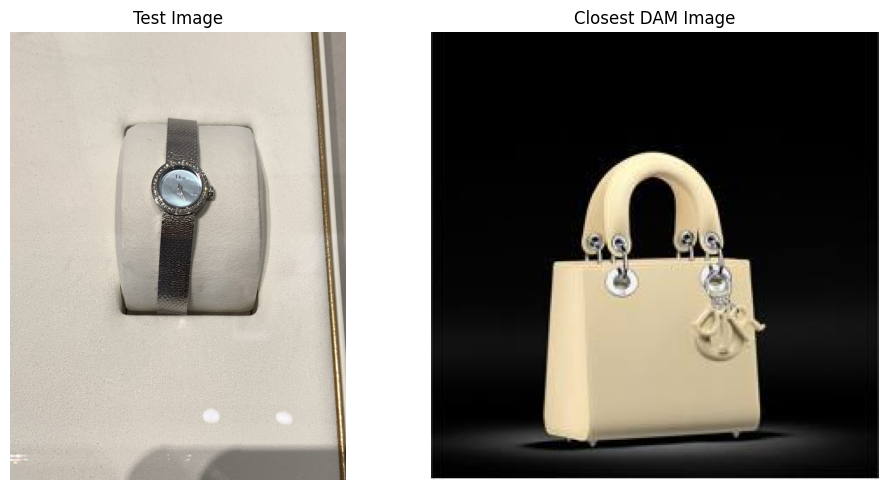

In [51]:
# --- Bloc 2 : Recherche de l'image la plus proche ---

def find_closest_image(test_image_path, model, dam_embeddings, dam_paths):
    """
    Trouve l'image la plus proche dans DAM pour une image de test.
    """
    # Load and preprocess the test image
    test_image = Image.open(test_image_path).convert("RGB")
    test_image = transform(test_image).unsqueeze(0)  # Add batch dimension

    # Extract embedding for the test image
    with torch.no_grad():
        test_embedding = model(test_image).squeeze().cpu().numpy()

    # Compute cosine similarity
    similarities = cosine_similarity(test_embedding.reshape(1, -1), dam_embeddings)
    closest_idx = np.argmax(similarities)
    closest_image_path = dam_paths[closest_idx]

    return closest_image_path




# Exemple d'utilisation ---

# Choisir une image aléatoire de test
test_dataset = ImageDataset(test_folder, transform=transform)
random_idx = random.randint(0, len(test_dataset) - 1)
test_image, test_path = test_dataset[random_idx]

# Trouver l'image la plus proche
closest_image_path = find_closest_image(test_path, resnet, dam_embeddings, dam_paths)

# Afficher l'image de test et l'image correspondante
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Test image
axes[0].imshow(Image.open(test_path))
axes[0].set_title("Test Image")
axes[0].axis("off")

# Closest DAM image
axes[1].imshow(Image.open(closest_image_path))
axes[1].set_title("Closest DAM Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()